# Unit 5 Exercise — Training Your Own Skip-gram

**Names:** Joeross Palabrica & Melissa Marielle Valdez  
**Section:** BSCS 3B  
**Date:** April 6, 2026

---

Train a word embedding model using the **skip-gram architecture with negative sampling**, then evaluate whether the learned vectors capture useful semantic relationships.

## Imports & Setup

Import all required libraries and set the global random seed for reproducibility.

In [1]:
import re, math, json, random
from typing import List, Tuple, Dict
import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

WIKI_URL = "https://en.wikipedia.org/wiki/Elvis_Presley"
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## NLTK Setup

Download the required NLTK tokenizer resources if they are not already present.

In [2]:
def ensure_nltk():
    for r in ["punkt", "punkt_tab"]:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

ensure_nltk()

## Step 1 — Fetch the Wikipedia Article

Download the **Elvis Presley** Wikipedia article and extract clean paragraph text.

- Uses `requests` to fetch the page HTML
- Uses `BeautifulSoup` to extract all `<p>` and `<li>` tags from the content div
- Strips citation numbers (e.g. `[1]`) and normalizes whitespace

In [3]:
def fetch_wikipedia_article(url):
    resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    paragraphs = content_div.find_all(["p", "li"])
    text = "\n".join(p.get_text(" ", strip=True) for p in paragraphs if p.get_text(" ", strip=True))
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Downloading Wikipedia article: Elvis Presley...")
raw_text = fetch_wikipedia_article(WIKI_URL)
print(f"Article fetched. Total characters: {len(raw_text):,}")

Article fetched. Total characters: 175,482


## Step 2 — Preprocess the Text

Clean and tokenize the raw article text into a list of token lists (one per sentence).

Pipeline:
1. **Sentence tokenization** via `sent_tokenize()`
2. **Lowercasing** all text
3. **Punctuation removal** via regex — keeps letters, digits, and hyphens
4. **Word tokenization** via `word_tokenize()`
5. **Filtering** — removes pure digits, strips leading/trailing hyphens, drops tokens shorter than 2 characters
6. Discards sentences with **fewer than 3 tokens**

In [4]:
def preprocess_text(text):
    sentences = sent_tokenize(text)
    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue
        tokens = word_tokenize(sent)
        cleaned = [t.strip("-") for t in tokens if t.strip("-") and not t.isdigit() and len(t.strip("-")) >= 2]
        if len(cleaned) >= 3:
            processed.append(cleaned)
    return processed

def corpus_stats(sentences):
    flat = [w for s in sentences for w in s]
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(set(flat))
    }

print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"  {k}: {v}")

Preprocessing text...

=== Corpus Stats ===
  num_sentences: 1386
  num_tokens: 22315
  vocab_size: 4815


## Step 3 — Train the Skip-gram Model (window=5)

Train a **Word2Vec Skip-gram with Negative Sampling** model using the preprocessed corpus.

| Parameter | Value | Description |
|-----------|-------|-------------|
| `vector_size` | 100 | Embedding dimensions |
| `window` | 5 | Context window size |
| `sg` | 1 | Skip-gram architecture |
| `negative` | 10 | Negative samples per positive pair |
| `epochs` | 200 | Training passes over the corpus |
| `alpha` | 0.025 | Initial learning rate |

In [5]:
def train_sgns(sentences, window_size=5):
    return Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=window_size,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED
    )

print("Training Skip-gram (window=5)...")
model = train_sgns(sentences, window_size=5)
print(f"Vocabulary size learned: {len(model.wv)}")

Training Skip-gram (window=5)...
Vocabulary size learned: 4815


## Step 4 — Nearest Neighbors

Inspect the top-8 nearest neighbors for a set of Elvis Presley-related probe words using cosine similarity in the embedding space.

In [6]:
def has_word(model, word):
    return word in model.wv.key_to_index

def cosine(model, w1, w2):
    return float(cosine_similarity(
        model.wv[w1].reshape(1, -1),
        model.wv[w2].reshape(1, -1)
    )[0][0])

def print_top_neighbors(model, words, topn=8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            print(f"\n{word}:")
            for neigh, score in model.wv.most_similar(word, topn=topn):
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

probe_words = ["elvis", "presley", "music", "rock", "singer", "gospel", "hollywood", "army", "memphis", "album"]
print_top_neighbors(model, probe_words, topn=8)


=== Nearest Neighbors ===

elvis:
  stamp                0.5803
  trap                 0.5605
  cadillac             0.5561
  pink                 0.5494
  forever              0.5447
  immersive            0.5227
  theatrical           0.5203
  sandwich             0.5187

presley:
  triple               0.4274
  elvises              0.4252
  trap                 0.4244
  pink                 0.4103
  cadillac             0.3874
  building             0.3777
  twin                 0.3605
  stage                0.3541

music:
  fusing               0.5022
  norton               0.4897
  halls                0.4876
  grove                0.4845
  concepts             0.4837
  ear                  0.4810
  concise              0.4810
  handle               0.4807

rock:
  roll                 0.7001
  vicious              0.6156
  brutal               0.6004
  degenerate           0.5943
  ugly                 0.5934
  occupation           0.5745
  deejay               0.5620
  decried 

## Step 5 — Evaluate Embeddings (window=5)

Evaluate the model using two test sets:

- **Relatedness test** — compare predicted cosine similarity against gold scores for word pairs
- **Analogy test** — test vector arithmetic (e.g. `singer : music :: actor : ?`)
- **Direct similarity checks** — spot-check specific word pairs

In [7]:
def evaluate_relatedness(model, test_pairs):
    covered = []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            covered.append((w1, w2, score, cosine(model, w1, w2)))
    return {"covered_items": covered, "coverage": len(covered), "total": len(test_pairs)}

def evaluate_analogies(model, analogies):
    covered, correct, details = 0, 0, []
    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = [w for w, _ in model.wv.most_similar(positive=[b, c], negative=[a], topn=5)]
                hit = d in preds
                correct += int(hit)
                details.append({"analogy": f"{a}:{b}::{c}:?", "expected": d, "predictions": preds, "correct_in_top5": hit})
            except KeyError:
                pass
    return {"coverage": covered, "total": len(analogies), "accuracy_top5": correct / covered if covered else float("nan"), "details": details}

relatedness_test = [
    ("elvis",   "presley",   0.95),
    ("music",   "rock",      0.85),
    ("singer",  "musician",  0.90),
    ("album",   "record",    0.88),
    ("gospel",  "music",     0.75),
    ("hollywood","film",     0.80),
    ("army",    "military",  0.80),
    ("memphis", "tennessee", 0.85),
    ("elvis",   "kitchen",   0.02),
    ("music",   "tractor",   0.02),
    ("rock",    "gospel",    0.40),
    ("singer",  "film",      0.35),
]

analogy_test = [
    ("singer", "music",   "actor",    "film"),
    ("album",  "record",  "film",     "movie"),
    ("elvis",  "presley", "memphis",  "tennessee"),
    ("rock",   "guitar",  "gospel",   "choir"),
]

rel5 = evaluate_relatedness(model, relatedness_test)
print("=== Relatedness Test Set (window=5) ===")
print(f"Coverage: {rel5['coverage']}/{rel5['total']}")
for w1, w2, gold, pred in rel5["covered_items"]:
    print(f"  {w1:12s} - {w2:12s} | gold={gold:.2f}  pred={pred:.4f}")

an5 = evaluate_analogies(model, analogy_test)
print(f"\n=== Analogy Test Set (window=5) ===")
print(f"Coverage: {an5['coverage']}/{an5['total']},  Top-5 accuracy: {an5['accuracy_top5']}")
for item in an5["details"]:
    print(json.dumps(item, ensure_ascii=False))

print("\n=== Direct Similarity Checks (window=5) ===")
check_pairs = [("elvis","presley"),("music","rock"),("singer","musician"),("elvis","kitchen")]
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"  {w1:12s} <-> {w2:12s}: {cosine(model, w1, w2):.4f}")
    else:
        print(f"  {w1:12s} <-> {w2:12s}: OOV")

=== Relatedness Test Set (window=5) ===
Coverage: 10/12
  elvis        - presley      | gold=0.95  pred=0.3298
  music        - rock         | gold=0.85  pred=0.1888
  singer       - musician     | gold=0.90  pred=0.3389
  album        - record       | gold=0.88  pred=0.2419
  gospel       - music        | gold=0.75  pred=0.4045
  hollywood    - film         | gold=0.80  pred=0.3133
  army         - military     | gold=0.80  pred=0.4732
  memphis      - tennessee    | gold=0.85  pred=0.4723
  rock         - gospel       | gold=0.40  pred=0.3054
  singer       - film         | gold=0.35  pred=0.2686

=== Analogy Test Set (window=5) ===
Coverage: 4/4,  Top-5 accuracy: 0.0
{"analogy": "singer:music::actor:?", "expected": "film", "predictions": ["catalog", "magical", "methadone", "detoxification", "manage"], "correct_in_top5": false}
{"analogy": "album:record::film:?", "expected": "movie", "predictions": ["australian-produced", "grossed", "fifth-highest-grossing", "rhapsody", "frequented"]

## Step 6 — Retrain with window=10

Retrain the model with a **larger context window (10)** and compare the results.

> A larger window captures broader, more topical co-occurrences rather than tight positional relationships. On a small corpus, this tends to dilute the training signal.

In [8]:
print("Retraining with window=10...")
model_w10 = train_sgns(sentences, window_size=10)
print(f"Vocabulary size learned: {len(model_w10.wv)}")

rel10 = evaluate_relatedness(model_w10, relatedness_test)
print("\n=== Relatedness Test Set (window=10) ===")
print(f"Coverage: {rel10['coverage']}/{rel10['total']}")
for w1, w2, gold, pred in rel10["covered_items"]:
    print(f"  {w1:12s} - {w2:12s} | gold={gold:.2f}  pred={pred:.4f}")

an10 = evaluate_analogies(model_w10, analogy_test)
print(f"\n=== Analogy Test Set (window=10) ===")
print(f"Coverage: {an10['coverage']}/{an10['total']},  Top-5 accuracy: {an10['accuracy_top5']}")

print("\n=== Direct Similarity Checks (window=10) ===")
for w1, w2 in check_pairs:
    if has_word(model_w10, w1) and has_word(model_w10, w2):
        print(f"  {w1:12s} <-> {w2:12s}: {cosine(model_w10, w1, w2):.4f}")
    else:
        print(f"  {w1:12s} <-> {w2:12s}: OOV")

Retraining with window=10...
Vocabulary size learned: 4815

=== Relatedness Test Set (window=10) ===
Coverage: 10/12
  elvis        - presley      | gold=0.95  pred=0.3969
  music        - rock         | gold=0.85  pred=0.1674
  singer       - musician     | gold=0.90  pred=0.2109
  album        - record       | gold=0.88  pred=0.2254
  gospel       - music        | gold=0.75  pred=0.3782
  hollywood    - film         | gold=0.80  pred=0.2257
  army         - military     | gold=0.80  pred=0.3726
  memphis      - tennessee    | gold=0.85  pred=0.4054
  rock         - gospel       | gold=0.40  pred=0.2857
  singer       - film         | gold=0.35  pred=0.3076

=== Analogy Test Set (window=10) ===
Coverage: 4/4,  Top-5 accuracy: 0.0

=== Direct Similarity Checks (window=10) ===
  elvis        <-> presley     : 0.3969
  music        <-> rock        : 0.1674
  singer       <-> musician    : 0.2109
  elvis        <-> kitchen     : OOV


## Step 7 — PCA Visualization

Reduce the 100-dimensional word vectors to **2D using PCA** and visualize 20 Elvis Presley-related words.

Words visualized: `elvis`, `presley`, `music`, `rock`, `singer`, `gospel`, `hollywood`, `army`, `memphis`, `album`, `film`, `television`, `concert`, `guitar`, `recording`, `fame`, `career`, `tour`, `mississippi`, `graceland`

PCA plot saved to: pca_elvis.png


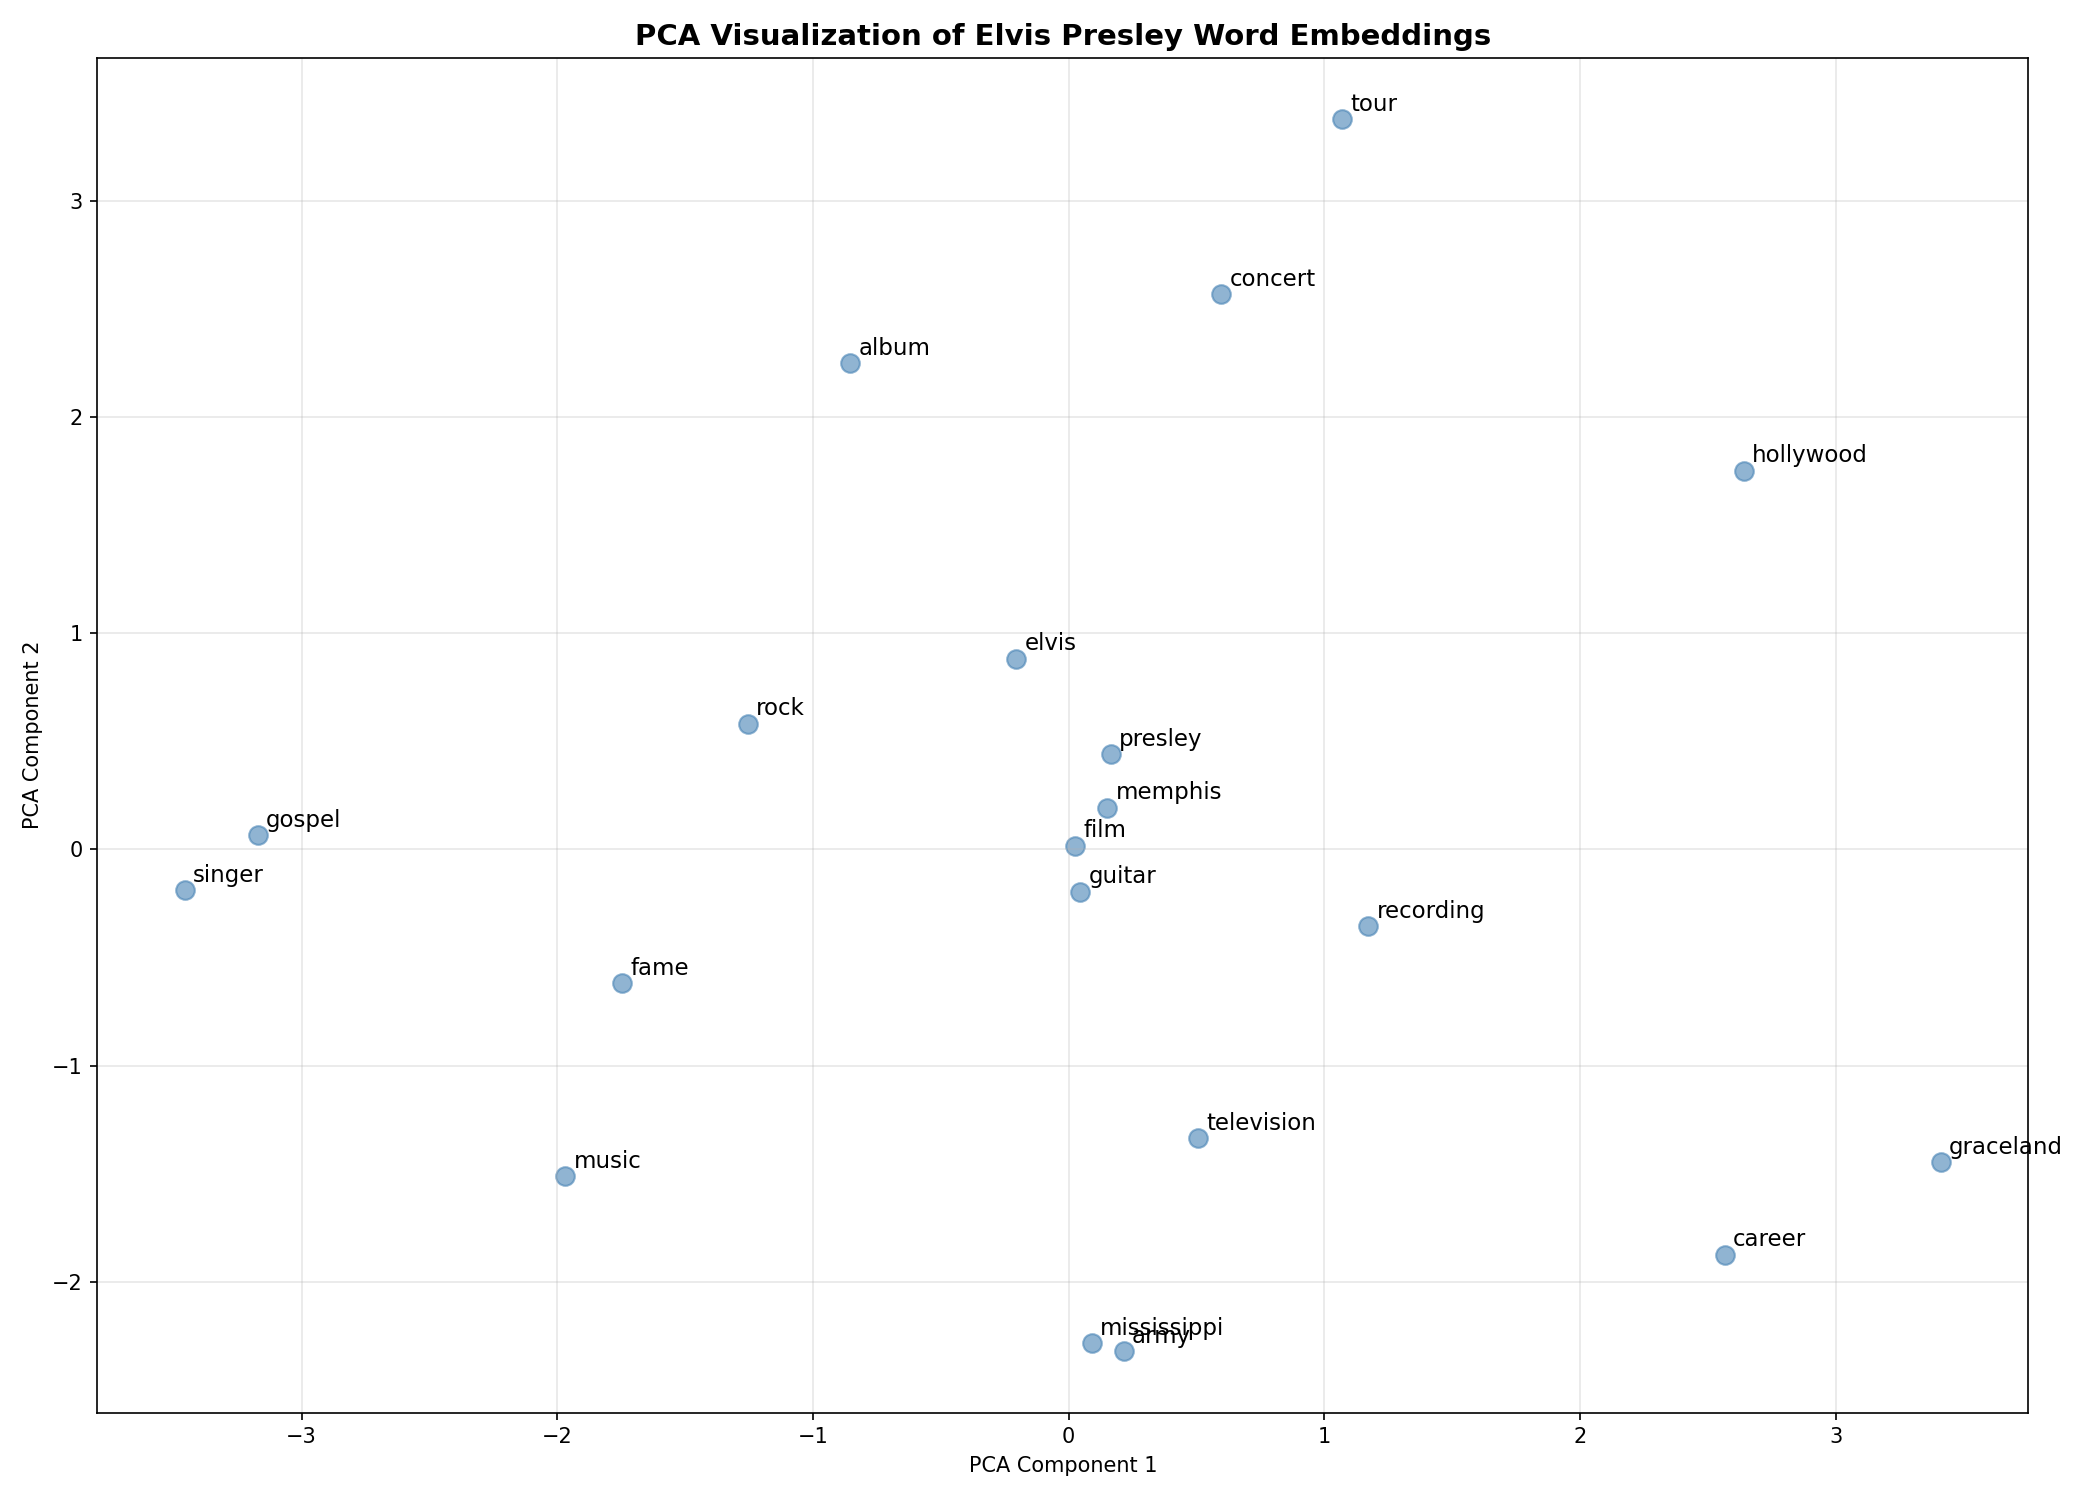

In [9]:
def visualize_pca(model, words, filename):
    valid = [w for w in words if has_word(model, w)]
    vectors = np.array([model.wv[w] for w in valid])
    coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(vectors)
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=80, color='steelblue')
    for i, word in enumerate(valid):
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=11,
                    xytext=(4, 4), textcoords='offset points')
    ax.set_title("PCA Visualization of Elvis Presley Word Embeddings", fontsize=14, fontweight='bold')
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()
    print(f"PCA plot saved to: {filename}")

pca_words = [
    "elvis", "presley", "music", "rock", "singer", "gospel",
    "hollywood", "army", "memphis", "album", "film", "television",
    "concert", "guitar", "recording", "fame", "career", "tour",
    "mississippi", "graceland"
]

visualize_pca(model, pca_words, "pca_elvis.png")

from IPython.display import Image
Image("pca_elvis.png")

## Step 8 — Save Models

Save both trained models to disk for future use.

In [10]:
model.save("exercise_5_skipgram_elvis.model")
model_w10.save("exercise_5_skipgram_elvis_w10.model")
print("Models saved:")
print("  exercise_5_skipgram_elvis.model       (window=5)")
print("  exercise_5_skipgram_elvis_w10.model   (window=10)")
print("\nDone.")

Models saved:
  exercise_5_skipgram_elvis.model       (window=5)
  exercise_5_skipgram_elvis_w10.model   (window=10)

Done.
